In [1]:
from skimage.metrics import structural_similarity as ssim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
from torch import nn
import matplotlib.pyplot as plt
import torchvision
import torch.optim as optim
import torch.nn.functional as F
from sklearn.cluster import KMeans
from tqdm import tqdm
import torch


# TODO: 4 x 4 patch'us VQ-VAE
# TODO: Try reading pixel hit events. Try code examples for reading.

In [2]:
# Selecting GPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Applying seed for reproducability
seed_value = 123

if device.type == "cuda":
    torch.cuda.manual_seed_all(seed_value)
else:
    torch.cuda.manual_seed(seed_value)

device

device(type='cuda')

In [3]:
# Params
batch_size = 64
learning_rate = 1e-2
# num_epochs = 80
num_epochs = 10
image_size = 18
channels = 1
latent_dim = 64
num_embeddings = 128  # Number of vectors in the codebook
beta = 0.2  # Beta, the commitment loss weight
num_residual_hiddens = 2
num_residual_layers = latent_dim // 2

In [4]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Resize((image_size, image_size)),
])

train_dataset = datasets.MNIST(root='./data', train=True, transform=transform, download=True)
train_loader = DataLoader(dataset=train_dataset, batch_size=batch_size, shuffle=True)

In [5]:
test_image, _ = next(iter(train_loader))
test_image.shape

torch.Size([64, 1, 18, 18])

In [6]:
test_image[1][0][0]

tensor([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.])

In [7]:
def show_image(batch_of_tensors):
    images = batch_of_tensors[:4]

    print(f"Plotting image shape: {images[0].shape}")

    grid_img = torchvision.utils.make_grid(images, nrow=2)

    grid_img = grid_img.detach().cpu()

    plt.figure(figsize=(2,2))
    
    print("Before")
    print(grid_img.shape)
    print("After")
    print(grid_img.permute(1,2,0).shape)
    
    plt.imshow(grid_img.permute(1,2,0), cmap='gray')
    plt.axis("off")
    plt.show()

In [8]:
class VQEmbedding(nn.Module):
    def __init__(self, num_embeddings, embedding_dim):
        super().__init__()
        self.embedding_dim = embedding_dim
        self.num_embeddings = num_embeddings

        self.embedding = nn.Embedding(num_embeddings, embedding_dim)
        self.embedding.weight.data.uniform_(-1/self.num_embeddings, 1/self.num_embeddings)

    def forward(self, z):
        # b = batch size
        # c = number of channels
        # h = height
        # w = width
        b, c, h, w = z.shape
        z_channel_last = z.permute(0, 2, 3, 1)
        z_flattened = z_channel_last.reshape(b*h*w, self.embedding_dim)

        # Calculate distances between z and the codebook embeddings |a-b|²
        # Euclidean distance. Form applied for efficiency in deep learning. In literature l2 distance is used.
        distances = (
            torch.sum(z_flattened ** 2, dim=-1, keepdim=True)                 # a²
            + torch.sum(self.embedding.weight.t() ** 2, dim=0, keepdim=True)  # b²
            - 2 * torch.matmul(z_flattened, self.embedding.weight.t())        # -2ab
        )

        # Get the index with the smallest distance
        # Finds minimum indexes at each row. Uses nearest neigboor look up
        encoding_indices = torch.argmin(distances, dim=-1)

        # Get the quantized vector
        z_q = self.embedding(encoding_indices)
        # when we find the indexes feature vectors, we reshape them to the encoder latent 
        # representation shape
        z_q = z_q.reshape(b, h, w, self.embedding_dim)
        
        # changed the order of the reshaped z_q
        z_q = z_q.permute(0, 3, 1, 2)

        # Calculate the commitment loss
        # Measures how closely the encoder outputs and the selected codebook embeddings match each other.
        reconstruction_loss = F.mse_loss(z_q, z.detach())
        commitment_loss = F.mse_loss(z_q.detach(), z)
        loss = reconstruction_loss + beta * commitment_loss

        # Straight-through estimator trick for gradient backpropagation
        # Finding closer membership to indexes
        z_q = z + (z_q - z).detach()

        return z_q, loss, encoding_indices

In [9]:
class Residual(nn.Module):
    """
    Residual Convolutional Layer
    """

    def __init__(self, in_channels, num_hiddens, num_residual_hiddens):
        """
        initialize residual CNN layer

        :param in_channels number: Number of input channels
        :param num_hiddens number: Number of hidden channels
        :param num_residual_hiddens number: Number of residual hiddens
        """
        super(Residual, self).__init__()
        self._block = nn.Sequential(
            nn.ReLU(True),
            # C: 3 -> residual hidden
            nn.Conv2d(
                in_channels=in_channels,
                out_channels=num_residual_hiddens,
                kernel_size=2,
                stride=1,
                padding=1,
                bias=False,
            ),
            nn.ReLU(True),
            # C: resiual hidden -> out_hidden
            nn.Conv2d(
                in_channels=num_residual_hiddens,
                out_channels=num_hiddens,
                kernel_size=2,
                stride=1,
                bias=False,
            ),
        )

    def forward(self, x):
        """
        Residual layer

        :param x numpy.ndarray: Input image
        """
        return x + self._block(x)  # residual output


class ResidualStack(nn.Module):
    """
    Residual Convolution Stack
    """

    def __init__(
        self, in_channels, num_hiddens, num_residual_layers, num_residual_hiddens
    ):
        """
        initialize residual stack

        :param in_channels number: Number of input channels
        :param num_hiddens number: Number of hidden channels
        :param num_residual_layers number: Number of residual layers in stack
        :param num_residual_hiddens number: Number of hidden residual channels
        """
        super(ResidualStack, self).__init__()
        self._num_residual_layers = num_residual_layers
        self._layers = nn.ModuleList(
            [
                Residual(in_channels, num_hiddens, num_residual_hiddens)
                for _ in range(self._num_residual_layers)
            ]
        )

    def forward(self, x):
        """
        Apply residual stack

        :param x numpy.ndarray: Input image
        """
        # Apply all residual layers in stack
        for i in range(self._num_residual_layers):
            x = self._layers[i](x)
        return F.relu(x)

In [10]:
class VQVAE(nn.Module):
    def __init__(self):
        super(VQVAE, self).__init__()

        # Encoder
        self.encoder = nn.Sequential(
            nn.Conv2d(channels, 8, kernel_size=2, stride=2, padding=1),
            ResidualStack(
                in_channels=8,
                num_hiddens=8,
                num_residual_layers=num_residual_layers,
                num_residual_hiddens=num_residual_hiddens,
            ),
            nn.ReLU(),
            nn.Conv2d(8, 16, kernel_size=2, stride=2, padding=1),
            nn.ReLU(),
            nn.Conv2d(16, 32, kernel_size=2, stride=2, padding=1),
            nn.ReLU(),
            nn.Conv2d(32, latent_dim, kernel_size=1)
        )

        # Vector Quantization
        self.vq_layer = VQEmbedding(num_embeddings, latent_dim)
        
        self.vq_residual = ResidualStack(
            in_channels=latent_dim,
            num_hiddens=latent_dim,
            num_residual_layers=latent_dim,
            num_residual_hiddens=num_residual_hiddens,
        )

        # Decoder
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(latent_dim, 32, kernel_size=1),
            ResidualStack(
                in_channels=32,
                num_hiddens=32,
                num_residual_layers=num_residual_layers,
                num_residual_hiddens=num_residual_hiddens,
            ),
            nn.ReLU(),
            nn.ConvTranspose2d(32, 16, kernel_size=2, stride=2, padding=1),
            nn.ReLU(),
            nn.ConvTranspose2d(16, 8, kernel_size=2, stride=2, padding=1),
            nn.ReLU(),
            nn.ConvTranspose2d(8, channels, kernel_size=2, stride=2, padding=1),
            nn.Tanh()  # Output values in range [-1, 1]
        )

    def forward(self, x):
        z_e = self.encoder(x)
        
        z_q, vq_loss, encodings = self.vq_layer(z_e)
        # print(f"Compressed shape: {z_q.shape}")
        
        # row level mean
        counts = torch.bincount(
            encodings,
            minlength=num_embeddings
        ).float()
        
        avg_probs = counts / counts.sum()
        perplexity = torch.exp(-torch.sum(avg_probs * torch.log(avg_probs + 1e-10)))
        
        x_recon = self.decoder(z_q)
        return x_recon, vq_loss, perplexity

In [11]:
model = VQVAE().to(device)
optimizer = optim.Adam(
    model.parameters(), 
    lr=learning_rate, 
    amsgrad=True
)

In [12]:
def _get_vq_loss(recon_x, x, vq_loss):
    recon_loss = F.mse_loss(recon_x, x)
    return recon_loss + vq_loss

Epoch 1/10: 100%|██████████| 938/938 [00:08<00:00, 110.56it/s, Loss=0.0257]


Epoch [1/10] Average Loss: 0.0005
Printing before/after reconstruction
Plotting image shape: torch.Size([1, 18, 18])
Before
torch.Size([3, 42, 42])
After
torch.Size([42, 42, 3])


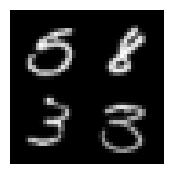

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.12475683..0.9379376].


Plotting image shape: torch.Size([1, 18, 18])
Before
torch.Size([3, 42, 42])
After
torch.Size([42, 42, 3])


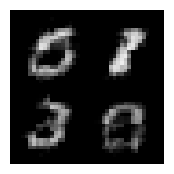

SSIM simalarity: 0.74


Epoch 2/10: 100%|██████████| 938/938 [00:08<00:00, 111.47it/s, Loss=0.0167]


Epoch [2/10] Average Loss: 0.0003
Printing before/after reconstruction
Plotting image shape: torch.Size([1, 18, 18])
Before
torch.Size([3, 42, 42])
After
torch.Size([42, 42, 3])


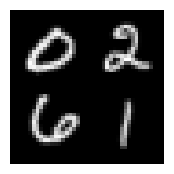

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.21687542..0.9321137].


Plotting image shape: torch.Size([1, 18, 18])
Before
torch.Size([3, 42, 42])
After
torch.Size([42, 42, 3])


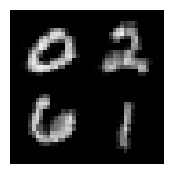

SSIM simalarity: 0.87


Epoch 3/10: 100%|██████████| 938/938 [00:08<00:00, 105.50it/s, Loss=0.0134]


Epoch [3/10] Average Loss: 0.0003
Printing before/after reconstruction
Plotting image shape: torch.Size([1, 18, 18])
Before
torch.Size([3, 42, 42])
After
torch.Size([42, 42, 3])


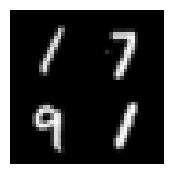

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.12362905..0.9113527].


Plotting image shape: torch.Size([1, 18, 18])
Before
torch.Size([3, 42, 42])
After
torch.Size([42, 42, 3])


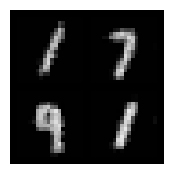

SSIM simalarity: 0.83


Epoch 4/10: 100%|██████████| 938/938 [00:08<00:00, 110.36it/s, Loss=0.017] 


Epoch [4/10] Average Loss: 0.0002
Printing before/after reconstruction
Plotting image shape: torch.Size([1, 18, 18])
Before
torch.Size([3, 42, 42])
After
torch.Size([42, 42, 3])


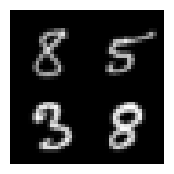

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.14700688..0.9155092].


Plotting image shape: torch.Size([1, 18, 18])
Before
torch.Size([3, 42, 42])
After
torch.Size([42, 42, 3])


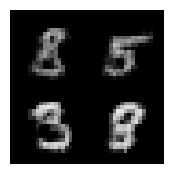

SSIM simalarity: 0.73


Epoch 5/10: 100%|██████████| 938/938 [00:07<00:00, 117.25it/s, Loss=0.0145]


Epoch [5/10] Average Loss: 0.0002
Printing before/after reconstruction
Plotting image shape: torch.Size([1, 18, 18])
Before
torch.Size([3, 42, 42])
After
torch.Size([42, 42, 3])


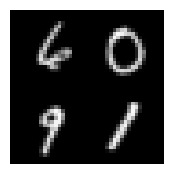

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.1090098..0.9111231].


Plotting image shape: torch.Size([1, 18, 18])
Before
torch.Size([3, 42, 42])
After
torch.Size([42, 42, 3])


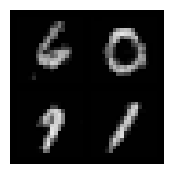

SSIM simalarity: 0.77


Epoch 6/10: 100%|██████████| 938/938 [00:08<00:00, 109.06it/s, Loss=0.0133]

Epoch [6/10] Average Loss: 0.0002
Printing before/after reconstruction
Plotting image shape: torch.Size([1, 18, 18])
Before
torch.Size([3, 42, 42])
After
torch.Size([42, 42, 3])


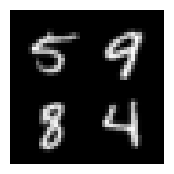

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.20584129..0.8914295].


Plotting image shape: torch.Size([1, 18, 18])
Before
torch.Size([3, 42, 42])
After
torch.Size([42, 42, 3])


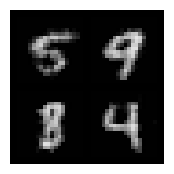

SSIM simalarity: 0.76


Epoch 7/10: 100%|██████████| 938/938 [00:08<00:00, 111.81it/s, Loss=0.0139]


Epoch [7/10] Average Loss: 0.0002
Printing before/after reconstruction
Plotting image shape: torch.Size([1, 18, 18])
Before
torch.Size([3, 42, 42])
After
torch.Size([42, 42, 3])


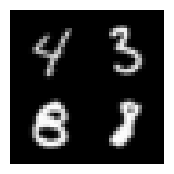

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.1664575..0.975697].


Plotting image shape: torch.Size([1, 18, 18])
Before
torch.Size([3, 42, 42])
After
torch.Size([42, 42, 3])


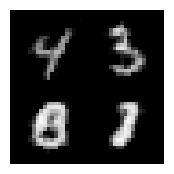

SSIM simalarity: 0.81


Epoch 8/10: 100%|██████████| 938/938 [00:08<00:00, 114.63it/s, Loss=0.0151]

Epoch [8/10] Average Loss: 0.0002
Printing before/after reconstruction
Plotting image shape: torch.Size([1, 18, 18])
Before
torch.Size([3, 42, 42])
After
torch.Size([42, 42, 3])


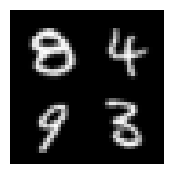

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.19069175..0.95298046].


Plotting image shape: torch.Size([1, 18, 18])
Before
torch.Size([3, 42, 42])
After
torch.Size([42, 42, 3])


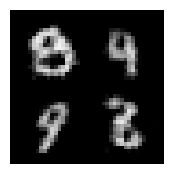

SSIM simalarity: 0.88


Epoch 9/10: 100%|██████████| 938/938 [00:08<00:00, 114.05it/s, Loss=0.0126]


Epoch [9/10] Average Loss: 0.0002
Printing before/after reconstruction
Plotting image shape: torch.Size([1, 18, 18])
Before
torch.Size([3, 42, 42])
After
torch.Size([42, 42, 3])


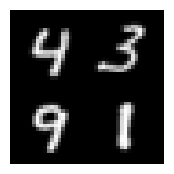

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.104589716..0.9733879].


Plotting image shape: torch.Size([1, 18, 18])
Before
torch.Size([3, 42, 42])
After
torch.Size([42, 42, 3])


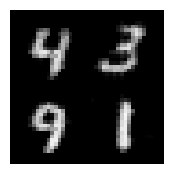

SSIM simalarity: 0.90


Epoch 10/10: 100%|██████████| 938/938 [00:18<00:00, 50.13it/s, Loss=0.0112] 


Epoch [10/10] Average Loss: 0.0002
Printing before/after reconstruction
Plotting image shape: torch.Size([1, 18, 18])
Before
torch.Size([3, 42, 42])
After
torch.Size([42, 42, 3])


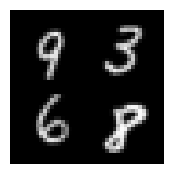

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.109386206..0.9678115].


Plotting image shape: torch.Size([1, 18, 18])
Before
torch.Size([3, 42, 42])
After
torch.Size([42, 42, 3])


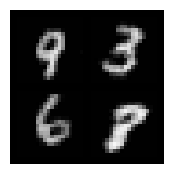

SSIM simalarity: 0.84
Saving trained model VQ-VAE


In [13]:
# Training Loop
reconstructed_images = []

# initial images before reconstruction
images_org = []

# loss
average_loss_values = []

# ssim
ssim_values = []

# perplexity
perplixty_values = []

for epoch in range(num_epochs):
    model.train()
    train_loss = 0

    # Use tqdm for the progress bar
    pbar = tqdm(enumerate(train_loader), total=len(train_loader), desc=f'Epoch {epoch+1}/{num_epochs}')

    for batch_idx, (data, _) in pbar:
        data = data.to(device)
        images_org.append(data)

        optimizer.zero_grad()
        recon_batch, vq_loss, perplexity = model(data)
        
        reconstructed_images.append(recon_batch)        
        
        loss = _get_vq_loss(recon_batch, data, vq_loss)
        loss.backward()
        train_loss += loss.item()
        optimizer.step()        

        # Update tqdm description with current loss
        pbar.set_postfix({'Loss': loss.item()})

    avg_loss = train_loss / len(train_loader.dataset)
    average_loss_values.append(avg_loss)
    perplixty_values.append(perplexity.cpu().numpy())
    
    print(f'Epoch [{epoch + 1}/{num_epochs}] Average Loss: {avg_loss:.4f}')

    # if epoch % 10 == 0:
    with torch.no_grad():
        print("Printing before/after reconstruction")
        recon_batch, _, _ = model(data)
        show_image(data.cpu())
        show_image(recon_batch.cpu())
        
        # calculating ssmi
        sample_image = data[0].squeeze().cpu().numpy()
        recon_batch_image = recon_batch[0].squeeze().cpu().numpy()
        recon_min_value = recon_batch_image.min()
        recon_max_value = recon_batch_image.max()
        
        ssmi_value = ssim(
            sample_image, 
            recon_batch_image, 
            data_range=recon_max_value - recon_min_value,
            win_size=5
        )
        print(f"SSIM simalarity: {ssmi_value:.2f}")
        ssim_values.append(ssmi_value)

# TODO: do you truly need to save the model?
print("Saving trained model VQ-VAE")
torch.save(model.state_dict(), "vqvae.pth")

In [24]:
with torch.no_grad():
    image, _ = next(iter(train_loader))
    image = image.to(device)
    model = VQVAE().to(device)
    z_latent_output = model.encoder(image)
    print(z_latent_output.shape)

    z = z_latent_output
    z = model.vq_residual(z)

    z = z.permute(0, 2, 3, 1)

    # flatten spatial grid
    z = z.reshape(-1, z.shape[-1])

    # convert to numpy
    z = z.detach().cpu().numpy()
    print(z.shape)

torch.Size([64, 64, 4, 4])
(1024, 64)


In [15]:
kmeans = KMeans(n_clusters=num_embeddings, random_state=seed_value)
labels = kmeans.fit_predict(z)
labels

array([101,  38,  20, ...,  39,  79,   6], shape=(1024,), dtype=int32)

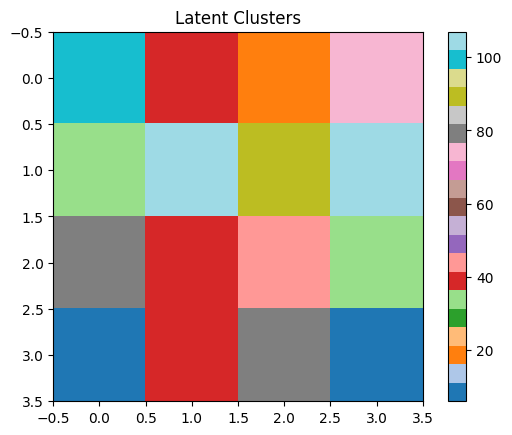

In [16]:
labels = labels.reshape(64, 4, 4)
plt.imshow(labels[0], cmap="tab20")
plt.title("Latent Clusters")
plt.colorbar()
plt.show()

Plotting image shape: torch.Size([1, 18, 18])
Before
torch.Size([3, 42, 42])
After
torch.Size([42, 42, 3])


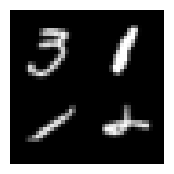

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.08229011..0.98284245].


Plotting image shape: torch.Size([1, 18, 18])
Before
torch.Size([3, 42, 42])
After
torch.Size([42, 42, 3])


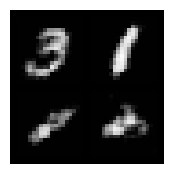

In [17]:
# Testing model with new data
# TODO: fix random noise in reconstruction image
model.load_state_dict(torch.load("vqvae.pth"))
model = model.to(device)
model.eval()    
with torch.no_grad():
    images, _ = next(iter(train_loader))
    images = images.to(device)
    recon_batch, _, _ = model(images)
    show_image(images.cpu())
    show_image(recon_batch.cpu())

In [18]:
recon_batch.shape

torch.Size([64, 1, 18, 18])

Printing average loss


/tmp/ipykernel_3080458/2445385629.py:10: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


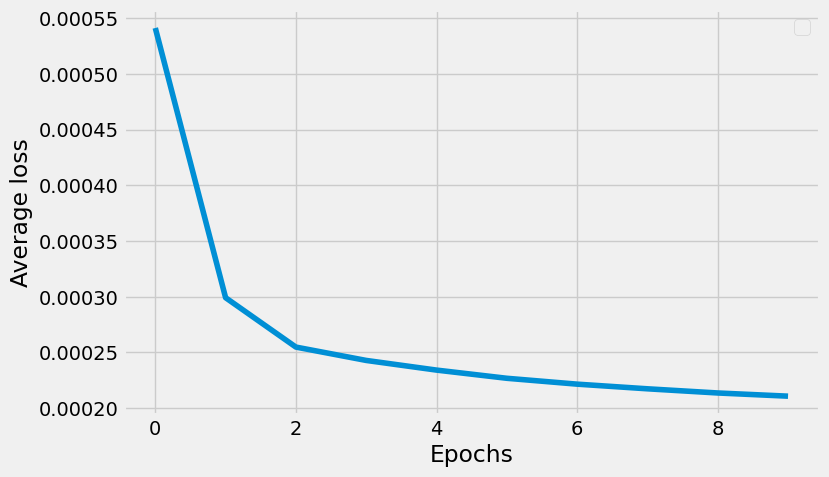

In [19]:
epoch_values = list(range(num_epochs))

def plot_loss_results(loss: list[float], epochs: int) -> None:
    print("Printing average loss")
    plt.style.use('fivethirtyeight')
    plt.figure(figsize=(8, 5))
    plt.plot(epochs, loss)
    plt.xlabel('Epochs')
    plt.ylabel('Average loss')
    plt.legend()
    plt.show()

plot_loss_results(average_loss_values, epoch_values)

ssmi values over epochs


/tmp/ipykernel_3080458/3037808170.py:10: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


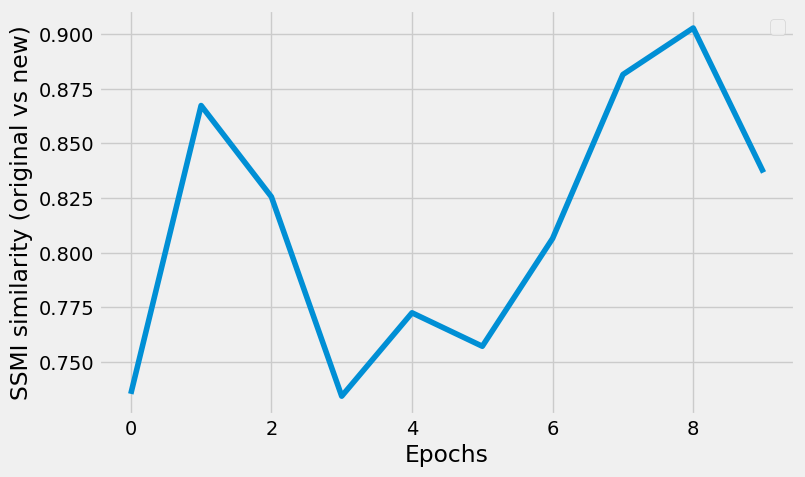

In [20]:
epoch_values = list(range(num_epochs))

def plot_ssim_results(ssim_values: list[float], epochs: int) -> None:
    print("ssmi values over epochs")
    plt.style.use('fivethirtyeight')
    plt.figure(figsize=(8, 5))
    plt.plot(epochs, ssim_values)
    plt.xlabel('Epochs')
    plt.ylabel('SSMI similarity (original vs new)')
    plt.legend()
    plt.show()

plot_ssim_results(ssim_values, epoch_values)

In [21]:
perplixty_values = list(map(float, perplixty_values))
perplixty_values = [round(val, 3) for val in perplixty_values]
perplixty_values

[24.099,
 34.653,
 36.055,
 42.156,
 40.973,
 38.048,
 39.213,
 44.368,
 37.537,
 40.956]

Perplexity values over epochs


/tmp/ipykernel_3080458/853153904.py:8: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


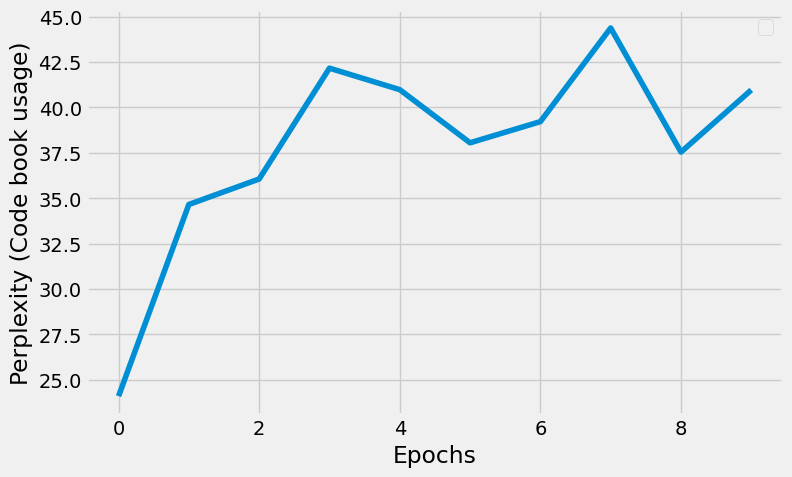

In [22]:
def plot_perplexity_results(perplixty_values: list[float], epochs: int) -> None:
    print("Perplexity values over epochs")
    plt.style.use('fivethirtyeight')
    plt.figure(figsize=(8, 5))
    plt.plot(epochs, perplixty_values)
    plt.xlabel('Epochs')
    plt.ylabel('Perplexity (Code book usage)')
    plt.legend()
    plt.show()

plot_perplexity_results(perplixty_values, epoch_values)